## Postdoc market simulation

First, some notes:

To be clear, the point of this is to measure the level of stochasticity in the postdoctoral market, in order to get a sense of the answer to the question: "***Given that I believe that I am ranked at some percentile in the global market, how many things should I apply to to be N percent certain of getting a job***".

### Number of available jobs

From AAS job postings + my own estimate, the number of available positions

| Category | Count |
| --- | --- |
| Society of Fellows (which may go to astronomers) |	5 |
| Prize / Independent Fellowships	| 36 (30-60) (but each of these on average x2)|
| Standard (non-prize) Postdocs | 194 (190-220)|
| **Total positions** | 255 |

### Number of graduating PhDs

US astro/astrophysics, 200-300 per year (http://nature.com/articles/d41586-019-00655-3 ).
China is probably 300-700 (actually more, look at Tsinghua https://astro.tsinghua.edu.cn/en/Teaching/Students.htm ), with maybe one half - one third entering the competion for these jobs listed above.
Europe similar 300-500+

Not counting cosmologists in physics departments. (adds maybe 20% to the total numbers)

Should also consider current postdocs re-applying: guesstimate that about 100 postdocs every year reapplying (1/6th of a given postdoc cohort will find faculty positions, 1/3 reapplies, the rest drop out of the field)

Statistics from different positions

- 700 for something like the Hubble/Soc-Fellows
- 200-500 applicants for a prize fellowships
- 100 applications for project postdoc

Typical number of applications sent in by each applicant 10-100 (truncated log-normal)
Applicants apply to at least 50% prize or above
Students are ranked based on a noisy perception of their ranking (draw perception of ranking from Mallows Model) - invite top 5% for interviews, and then redraw, with a less noisy draw, and offer the position to the 1 ranked candidate.

Next step - many good applicants will have many offers, but they can only accept 1.
Assume that they all accept the higher ranked fellowship in the first round, with the position then being offered to the second ranked applicant, iterate until convergence.

So the question is:

How many positions should I apply to, given that I am ranked somewhere in the:

Upper half, lower half, quartiles, if I don’t know anything, to have a (10, 50, 90)% chance of getting a position. Of getting a prize position?

The best possible model:

Draw an N-dimensional vector of relevant skills (code skill, pen-to-paper skill, project selection/intuition, prior experience, ability to work with others/personality, writing skills, outreach, etc.). This N-dimensional vector then gets projected (with some noise) onto the weight/preference vector of the hiring committee 

(Visualize this as a 3-dimensional vector)

Some inspiration from https://github.com/ekhiru/top-k-mallows/tree/master

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append('top-k-mallows')
import mallows_kendall as mk
import permutil as pu
import scipy as sp
import pandas as pd

In [7]:
perm1 = np.array([0,1,2,3,4])
perm2 = np.array([0, 2, 2, 1, 4])
mk.distance(perm1, perm2)

2

In [8]:
N_students = 1000
N_postdocs = 300
        # SocFellow, Prize, Project
splits = np.array([5, 50, 200])
splits = splits/np.sum(splits)

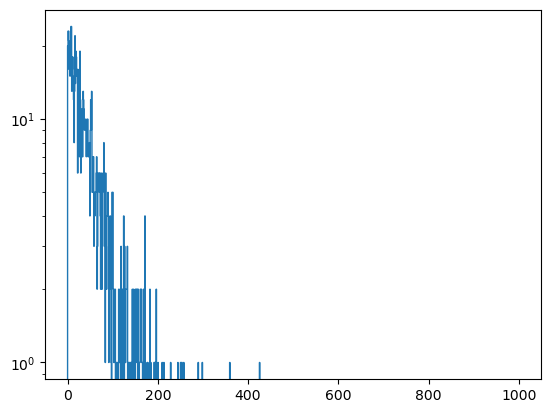

In [9]:
samps = mk.sample(m=1000,n=1000,phi=0.98)
plt.hist(samps[:,0], bins = np.arange(1000), histtype = 'step', log = 1);

In [10]:
# mk.sample(m=1,n=1000,phi=0.99)

In [11]:
class ApplicantCohort:
    def __init__(self, n_students = 1000, n_postdocs = 300, splits = np.array([6, 50, 200]), frac_student_applying = 3/4,
                 frac_postdoc_applying = 1/3, mean_applications = np.log(30), sigma_applications = 0.4, tier_max_prestige = [10, 15, 3],
                 prestige_decays = [1, 2, 1.2], minimum_prestiges = [5, 3, 1],
                 loc_postdoc_reapplying = 1.15, scale_postdoc_reapplying = 0.8, loc_student = 0, scale_student = 1,
                 self_awareness = 0.5, stochasticity = 0.98, verbose = 1):
        """Initializes the object"""

        self.n_students = n_students
        self.frac_student_applying = frac_student_applying
        self.n_student_applying = int(n_students*frac_student_applying)
        
        self.n_postdocs = n_postdocs
        self.frac_postdoc_applying = frac_postdoc_applying 
        self.n_postdoc_reapplying = int(n_postdocs*frac_postdoc_applying)
        
        self.splits = np.array(splits)
        self.splits = np.array([int(s) for s in self.splits])
        
        self.tier_max = np.array(tier_max_prestige)
        self.prestige_decay = prestige_decays
        self.minimum_prestiges = minimum_prestiges
        
        self.mean_applications = mean_applications
        self.sigma_applications = sigma_applications
        self.verbose = verbose
        
        self.n_positions = sum(splits)
        self.self_awareness = np.max( [ np.min([0.5, self_awareness]), 0 ] ) # highest is 0.5, lowest is 0
        self.stochasticity = stochasticity #closer to 1 is very stochastic, anything below 0.8 is quite deterministic
        
        ##################################################
        # Parameters for sampling ranks of students      #
        # and postdocs reapplying (normal distributions) #
        ##################################################
        self.loc_postdoc_reapplying = loc_postdoc_reapplying
        self.scale_postdoc_reapplying = scale_postdoc_reapplying

        self.loc_student = loc_student
        self.scale_student = scale_student
        
    def rank_applicants(self):
        """ This is where we create a ranked list of applicants (postdocs and students), with the top tail of the two being 
        roughly matched"""
        self.applicant_skill_students = np.random.normal(loc = self.loc_student, scale = self.scale_student,
                                                    size = self.n_student_applying)
        
        self.applicant_skill_postdocs = np.random.normal(loc = self.loc_postdoc_reapplying, scale = self.scale_postdoc_reapplying,
                                                    size = self.n_postdoc_reapplying)

        self.labels = np.array( ['student']*self.n_student_applying + ['postdoc']*self.n_postdoc_reapplying )
        self.all_skills = np.concatenate([-self.applicant_skill_students, -self.applicant_skill_postdocs])

        self.skills_sorted, self.labels_sorted = zip( *sorted( zip(self.all_skills, self.labels) ) ) 

        self.applicants = []
        for i in range(len(self.skills_sorted)):
            
            applicant = {'currently': self.labels_sorted[i],
                         'skill': -self.skills_sorted[i],
                         'rank': i,
                         'offers': [],
                         'offers_prestige': []}
            
            self.applicants.append(applicant)

        self.applicants_on_the_market = [i for i in range(len(self.skills_sorted))]
        
    def get_n_applications_per_applicant(self):
        """ Function to determine how many applications each applicant will send """
        self.n_applications = []
        mean_postdoc_applications = np.log( np.exp(self.mean_applications)/2 )
        
        for label in self.labels_sorted:
            if label == 'postdoc':
                self.n_applications.append(np.random.lognormal(mean = mean_postdoc_applications, sigma = self.sigma_applications, size=1))
            if label == 'student':
                self.n_applications.append(np.random.lognormal(mean = self.mean_applications, sigma = self.sigma_applications, size=1))
       
        self.n_applications =  [int(app) for app in self.n_applications]

        for i in range(len(self.n_applications)):
            self.applicants[i]['n_applications'] = self.n_applications[i]
            
    def build_prestige(self):
        ''' This module here is the weirdest, could probably pick a different function'''
        
        prestige = []
        
        for i in range(len(self.splits)):
            n, max_p, prestige_decay, min_prestige = self.splits[i], self.tier_max[i], self.prestige_decay[i], self.minimum_prestiges[i]
            ranks = np.arange(n)
            tier_values = max_p * np.exp(-prestige_decay/n * ranks) + min_prestige
            prestige.extend(tier_values)
        
        self.prestige = np.array(prestige)/4 #make everything flatter
        
    def make_application_pools(self):
        """ We now need to actually make an applicant pool for each position. Each position will have a global "attractiveness score", 
        that will be turned into a probability of any one applicant sending an application there. Better applicants will be more likely
        to apply to more attractive positions."""
        
        N_applicants = len(self.all_skills)
        N_positions = len(self.prestige)
    
        pools = [[] for _ in range(N_positions)]
    
        for i in range(N_applicants):
    
            beta_i = 0.5 - self.self_awareness*self.skills_sorted[i]/np.max(np.abs(self.skills_sorted),axis=0)
            print(beta_i)
            # softmax with skill-dependent sharpness beta (i.e., applicants have some self-awareness, and very skilled applicants
            # preferentially apply to high-prestige positions)
            
            logits = beta_i * self.prestige
            probs = np.exp(logits - np.max(logits))+0.05
            probs /= probs.sum()
    
            k = min(self.n_applications[i], N_positions) # not relevant but safe
            chosen = np.random.choice(
                N_positions,
                size=k,
                replace=False,
                p=probs
            )
    
            for pos in chosen:
                pools[pos].append(i)
    
        self.pools = pools
        self.jobs_still_open = [i for i in range(N_positions)]
        
    def evaluate_applications(self):
        ''' Here we use the Mallow's Model for top k ranked choice to actually rank the applications'''
        sys.path.append('top-k-mallows')
        import mallows_kendall as mk
        import permutil as pu

        n_samples = 1

        pool_rankings = []
        for pool in self.pools:
            samps = mk.sample(m = n_samples, n = len(pool), phi = self.stochasticity)
            pool_rankings.append(samps)
        
        self.pool_rankings = pool_rankings
        self.job_offer_pointer = [0] * len(self.pools)

    # def make_applicant_offers(self):
    #     print('Making offers')
    #     pool_index = 0
    #     for pool, prestige in zip( self.pool_rankings, self.prestige ):

    #         offered = False
    #         if pool_index in self.jobs_still_open:
    #             offer_to_index = 0
    #             print(len(pool[0]), pool_index)
    #             while offered == False:
    #                 offer_to = pool[0][offer_to_index]
    #                 if offer_to in self.applicants_on_the_market:
    #                     self.applicants[offer_to]['offers'].append(pool_index)
    #                     self.applicants[offer_to]['offers_prestige'].append(prestige)
    #                     offered = True
    #                 else:
    #                     offer_to_index+=1

    #         # This wonky workaround is not great
    #                     # if offer_to_index==len(pool[0]):
    #                     #     offer_to = np.random.choice(self.applicants_on_the_market)
                        
    #                     #     self.applicants[offer_to]['offers'].append(pool_index)
    #                     #     self.applicants[offer_to]['offers_prestige'].append(prestige)
    #                     #     offered = True
                        
    #         pool_index += 1
    def make_applicant_offers(self):
    
        if self.verbose >= 1:
            print("Making offers")
    
        for job_index, prestige in enumerate(self.prestige):
    
            if job_index not in self.jobs_still_open:
                continue
    
            pointer = self.job_offer_pointer[job_index]
    
            # SECOND CALL LOGIC
            if pointer >= len(self.pool_rankings[job_index][0]):
    
                # rebuild pool from remaining applicants
                remaining = self.applicants_on_the_market.copy()
    
                if len(remaining) == 0:
                    continue
    
                # simple deterministic ranking by skill
                remaining_sorted = sorted(
                    remaining,
                    key=lambda x: self.applicants[x]['skill'],
                    reverse=True
                )
    
                self.pool_rankings[job_index] = [remaining_sorted]
                self.job_offer_pointer[job_index] = 0
                pointer = 0
    
                if self.verbose >= 2:
                    print(f"Job {job_index} opens second call")
    
            ranked_list = self.pool_rankings[job_index][0]
    
            while pointer < len(ranked_list):
    
                offer_to = ranked_list[pointer]
                self.job_offer_pointer[job_index] += 1
                pointer += 1
    
                if offer_to not in self.applicants_on_the_market:
                    continue
    
                applicant = self.applicants[offer_to]
    
                # enforce application cap
                if len(applicant['offers']) >= applicant['n_applications']:
                    continue
    
                applicant['offers'].append(job_index)
                applicant['offers_prestige'].append(prestige)
    
                if self.verbose >= 2:
                    print(f"Job {job_index} offers to {offer_to}")
    
                break
                
    def accept_offer_round(self):
        applicants_accepting = []
        jobs_accepted = []
        for applicant in self.applicants:
            if applicant['rank'] in self.applicants_on_the_market:
                if len(applicant['offers'])>0:
                    perturbation = np.abs(np.random.normal(loc = 1, scale = 0.2))
                    offer_to_accept = applicant['offers'][np.argmax(np.array(applicant['offers_prestige'])*perturbation)]
                    jobs_accepted.append(offer_to_accept)
                    applicants_accepting.append(applicant['rank'])
                    
                    applicant['offer_accepted'] = offer_to_accept
                    applicant['offer_accepted_round'] = self.round
                    self.applicant_post_acceptance.append(applicant)

        print(f'Total jobs accepted {len(applicants_accepting)}')
        for applicant, job in zip(applicants_accepting, jobs_accepted):
            self.applicants_on_the_market.remove(applicant)
            self.jobs_still_open.remove(job)
        
    def run_market(self, offer_rounds = 10):
        self.applicants_every_round = []
        self.applicant_post_acceptance = []
        
        self.rank_applicants()
        self.get_n_applications_per_applicant()
        self.build_prestige()
        self.make_application_pools()
        self.evaluate_applications()

        self.round = 1

        # for _ in range(offer_rounds):
        #     # self.clear_round_offers()
        #     self.make_applicant_offers()
        #     self.accept_offer_round()
        #     self.round+=1
        #     self.applicants_every_round.append(self.applicants)
        #     print(self.applicants_on_the_market)
        
        for _ in range(offer_rounds):
        
            self.make_applicant_offers()
            self.accept_offer_round()
        
            filled = len(self.applicant_post_acceptance)
        
            if self.verbose >= 1:
                print(f"Filled jobs so far: {filled}/{self.n_positions}")
        
            if len(self.jobs_still_open) == 0:
                break
        
            self.round += 1
            self.applicants_every_round.append(self.applicants)
            for applicant in self.applicants:
                applicant['offers'] = []
                applicant['offers_prestige'] = []

In [3]:
# Cohort = ApplicantCohort()
# # This works well for round 1, but not for round 2 and so on. Many applications get more offers than they've applied for
# Cohort.run_market(offer_rounds = 20)[0]

In [4]:
# Cohort.applicants_every_round

In [26]:
import numpy as np
import copy
import sys


class ApplicantCohort:

    def __init__(
        self,
        n_students=1000,
        n_postdocs=300,
        splits=np.array([6, 50, 200]),
        frac_student_applying=3/4,
        frac_postdoc_applying=1/3,
        mean_applications=np.log(30),
        sigma_applications=0.4,
        tier_max_prestige=[10, 15, 3],
        prestige_decays=[1, 2, 1.2],
        minimum_prestiges=[5, 3, 1],
        loc_postdoc_reapplying=1.3,
        scale_postdoc_reapplying=0.8,
        loc_student=0,
        scale_student=1,
        self_awareness=0.5,
        stochasticity=0.9,
        verbose=1
    ):

        self.verbose = verbose

        self.n_students = n_students
        self.n_postdocs = n_postdocs

        self.frac_student_applying = frac_student_applying
        self.frac_postdoc_applying = frac_postdoc_applying

        self.n_student_applying = int(n_students * frac_student_applying)
        self.n_postdoc_reapplying = int(n_postdocs * frac_postdoc_applying)

        self.splits = np.array([int(s) for s in splits])
        self.n_positions = sum(self.splits)

        self.tier_max = np.array(tier_max_prestige)
        self.prestige_decay = prestige_decays
        self.minimum_prestiges = minimum_prestiges

        self.mean_applications = mean_applications
        self.sigma_applications = sigma_applications

        self.self_awareness = np.clip(self_awareness, 0, 0.5)
        self.stochasticity = stochasticity

        self.loc_postdoc_reapplying = loc_postdoc_reapplying
        self.scale_postdoc_reapplying = scale_postdoc_reapplying
        self.loc_student = loc_student
        self.scale_student = scale_student

    ############################################################
    # 1️⃣ RANK APPLICANTS
    ############################################################

    def rank_applicants(self):

        skills_students = np.random.normal(
            self.loc_student,
            self.scale_student,
            self.n_student_applying
        )

        skills_postdocs = np.random.normal(
            self.loc_postdoc_reapplying,
            self.scale_postdoc_reapplying,
            self.n_postdoc_reapplying
        )

        labels = (
            ['student'] * self.n_student_applying +
            ['postdoc'] * self.n_postdoc_reapplying
        )

        all_skills = np.concatenate([skills_students, skills_postdocs])

        order = np.argsort(-all_skills)

        self.applicants = []

        for rank, idx in enumerate(order):

            applicant = {
                "rank": rank,
                "skill": all_skills[idx],
                "currently": labels[idx],
                "n_applications": 0,
                "offers": [],
                "offers_prestige": [],
                "offers_this_round": [],
                "offers_prestige_this_round": [],
                "total_offers_received": 0,
                "accepted": False,
                "accepted_job": None,
                "accepted_round": None
            }

            self.applicants.append(applicant)

        self.applicants_on_the_market = list(range(len(self.applicants)))

    ############################################################
    # 2️⃣ APPLICATION COUNTS
    ############################################################

    def get_n_applications_per_applicant(self):

        mean_postdoc = np.log(np.exp(self.mean_applications) / 2)

        for applicant in self.applicants:

            if applicant["currently"] == "postdoc":
                n = np.random.lognormal(mean_postdoc, self.sigma_applications)
            else:
                n = np.random.lognormal(self.mean_applications, self.sigma_applications)

            applicant["n_applications"] = int(max(1, n))

        if self.verbose >= 1:

            students = [a for a in self.applicants if a["currently"] == "student"]
            postdocs = [a for a in self.applicants if a["currently"] == "postdoc"]

            print("\n--- APPLICATION STATISTICS ---")
            print(f"Students applying: {len(students)}")
            print(f"Postdocs applying: {len(postdocs)}")
            print(f"Mean applications (students): {np.mean([a['n_applications'] for a in students]):.2f}")
            print(f"Mean applications (postdocs): {np.mean([a['n_applications'] for a in postdocs]):.2f}")
            print(f"Total positions: {self.n_positions}")
            print("--------------------------------")

    ############################################################
    # 3️⃣ BUILD PRESTIGE
    ############################################################

    def build_prestige(self):

        prestige = []

        for i in range(len(self.splits)):

            n = self.splits[i]
            ranks = np.arange(n)

            values = (
                self.tier_max[i] *
                np.exp(-self.prestige_decay[i] / n * ranks)
                + self.minimum_prestiges[i]
            )

            prestige.extend(values)

        self.prestige = np.array(prestige) / 4

    ############################################################
    # 4️⃣ APPLICATION POOLS
    ############################################################

    def make_application_pools(self):

        N_positions = len(self.prestige)
        self.pools = [[] for _ in range(N_positions)]

        max_skill = max(abs(a["skill"]) for a in self.applicants)

        for i, applicant in enumerate(self.applicants):

            beta = 0.5 - self.self_awareness * applicant["skill"] / max_skill

            logits = beta * self.prestige
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()

            k = min(applicant["n_applications"], N_positions)

            chosen = np.random.choice(
                N_positions,
                size=k,
                replace=False,
                p=probs
            )

            for pos in chosen:
                self.pools[pos].append(i)

        self.jobs_still_open = list(range(N_positions))
        self.job_offer_pointer = [0] * N_positions

    ############################################################
    # 5️⃣ EVALUATE APPLICATIONS
    ############################################################

    def evaluate_applications(self):

        sys.path.append('top-k-mallows')
        import mallows_kendall as mk

        self.pool_rankings = []

        for pool in self.pools:

            if len(pool) == 0:
                self.pool_rankings.append([[]])
                continue

            ranking = mk.sample(m=1, n=len(pool), phi=self.stochasticity)
            ordered = [pool[i] for i in ranking[0]]
            self.pool_rankings.append([ordered])

    ############################################################
    # 6️⃣ MAKE OFFERS
    ############################################################

    def make_applicant_offers(self):

        for job in self.jobs_still_open.copy():

            pointer = self.job_offer_pointer[job]
            ranked_list = self.pool_rankings[job][0]

            # SECOND CALL
            if pointer >= len(ranked_list):

                remaining = self.applicants_on_the_market

                if len(remaining) == 0:
                    continue

                ranked_list = sorted(
                    remaining,
                    key=lambda x: self.applicants[x]["skill"],
                    reverse=True
                )

                self.pool_rankings[job] = [ranked_list]
                self.job_offer_pointer[job] = 0
                pointer = 0

                if self.verbose >= 2:
                    print(f"Job {job} triggers SECOND CALL")

            while pointer < len(ranked_list):

                applicant_id = ranked_list[pointer]
                pointer += 1
                self.job_offer_pointer[job] = pointer

                if applicant_id not in self.applicants_on_the_market:
                    continue

                applicant = self.applicants[applicant_id]

                if applicant["total_offers_received"] >= applicant["n_applications"]:
                    continue

                applicant["offers_this_round"].append(job)
                applicant["offers_prestige_this_round"].append(self.prestige[job])

                applicant["offers"].append(job)
                applicant["offers_prestige"].append(self.prestige[job])

                applicant["total_offers_received"] += 1

                if self.verbose >= 2:
                    print(f"Job {job} offers to Applicant {applicant_id} "
                          f"({applicant['currently']})")

                break

    ############################################################
    # 7️⃣ ACCEPT OFFERS
    ############################################################

    def accept_offer_round(self):

        accepted_this_round = []

        for applicant_id in self.applicants_on_the_market.copy():

            applicant = self.applicants[applicant_id]

            if len(applicant["offers_this_round"]) == 0:
                continue

            perturb = np.abs(np.random.normal(1, 0.2))
            weighted = np.array(applicant["offers_prestige_this_round"]) * perturb

            chosen_index = np.argmax(weighted)
            chosen_job = applicant["offers_this_round"][chosen_index]

            applicant["accepted"] = True
            applicant["accepted_job"] = chosen_job
            applicant["accepted_round"] = self.round

            accepted_this_round.append(applicant_id)

            self.jobs_still_open.remove(chosen_job)

            if self.verbose >= 2:
                print(f"Applicant {applicant_id} ACCEPTS job {chosen_job} "
                      f"(sent {applicant['n_applications']} applications)")

        for a in accepted_this_round:
            self.applicants_on_the_market.remove(a)

        ########################################################
        # VERBOSE LEVEL 1 SUMMARY
        ########################################################

        if self.verbose >= 1 and len(accepted_this_round) > 0:

            accepted = [self.applicants[a] for a in accepted_this_round]

            students = [a for a in accepted if a["currently"] == "student"]
            postdocs = [a for a in accepted if a["currently"] == "postdoc"]

            print(f"\nROUND {self.round} SUMMARY")
            print(f"Accepted this round: {len(accepted)}")
            print(f"Students: {len(students)}, Postdocs: {len(postdocs)}")
            print(f"Mean applications sent (accepted): "
                  f"{np.mean([a['n_applications'] for a in accepted]):.2f}")
            print(f"Mean offers received (accepted): "
                  f"{np.mean([a['total_offers_received'] for a in accepted]):.2f}")
            print(f"Jobs remaining open: {len(self.jobs_still_open)}")
            print("--------------------------------")

        # Clear round offers only
        for applicant in self.applicants:
            applicant["offers_this_round"] = []
            applicant["offers_prestige_this_round"] = []

    ############################################################
    # 8️⃣ RUN MARKET
    ############################################################

    def run_market(self, offer_rounds=10):

        if self.verbose >= 1:
            print("\n=========== STARTING MARKET ===========")

        self.rank_applicants()
        self.get_n_applications_per_applicant()
        self.build_prestige()
        self.make_application_pools()
        self.evaluate_applications()

        self.round = 1

        for _ in range(offer_rounds):

            if len(self.jobs_still_open) == 0:
                break

            if len(self.applicants_on_the_market) == 0:
                break

            if self.verbose >= 1:
                print(f"\n--- ROUND {self.round} ---")
                print(f"Open jobs: {len(self.jobs_still_open)}")
                print(f"Applicants on market: {len(self.applicants_on_the_market)}")

            self.make_applicant_offers()
            self.accept_offer_round()

            self.round += 1

        if self.verbose >= 1:
        
            filled = [a for a in self.applicants if a["accepted"]]
            n_filled = len(filled)
        
            students_filled = sum(a["currently"] == "student" for a in filled)
            postdocs_filled = sum(a["currently"] == "postdoc" for a in filled)
        
            max_positions_anyone_got = max(
                [a["total_offers_received"] for a in self.applicants]
            )
        
            print("\n=========== MARKET CLOSED ===========")
            print(f"Total filled: {n_filled}/{self.n_positions}")
            print(f"Students placed: {students_filled} ({students_filled/self.n_students*100:.1f}%)")
            print(f"Postdocs placed: {postdocs_filled}  ({postdocs_filled/self.n_postdocs*100:.1f}%)")
            print(f"Unfilled jobs: {len(self.jobs_still_open)}")
            print(f"Maximum offers received by any applicant: {max_positions_anyone_got}")
            print("======================================")

        

In [27]:
Cohort = ApplicantCohort(stochasticity = 0.8)
# This works well for round 1, but not for round 2 and so on. Many applications get more offers than they've applied for
Cohort.run_market(offer_rounds = 20)


=========== STARTING MARKET ===========

--- APPLICATION STATISTICS ---
Students applying: 750
Postdocs applying: 100
Mean applications (students): 33.11
Mean applications (postdocs): 15.90
Total positions: 256
--------------------------------

--- ROUND 1 ---
Open jobs: 256
Applicants on market: 850

ROUND 1 SUMMARY
Accepted this round: 101
Students: 62, Postdocs: 39
Mean applications sent (accepted): 28.90
Mean offers received (accepted): 2.53
Jobs remaining open: 155
--------------------------------

--- ROUND 2 ---
Open jobs: 155
Applicants on market: 749

ROUND 2 SUMMARY
Accepted this round: 83
Students: 61, Postdocs: 22
Mean applications sent (accepted): 25.93
Mean offers received (accepted): 1.87
Jobs remaining open: 72
--------------------------------

--- ROUND 3 ---
Open jobs: 72
Applicants on market: 666

ROUND 3 SUMMARY
Accepted this round: 51
Students: 48, Postdocs: 3
Mean applications sent (accepted): 34.82
Mean offers received (accepted): 1.41
Jobs remaining open: 21
--

In [22]:
Cohort.applicants

[{'rank': 0,
  'skill': 3.367744928701108,
  'currently': 'student',
  'n_applications': 18,
  'offers': [21, 41, 92, 96, 126, 162, 177, 182, 250],
  'offers_prestige': [2.8080436353525995,
   1.6747386147810241,
   0.8543014764051098,
   0.8399708957999151,
   0.7427851148612925,
   0.6470543632815209,
   0.6128803648509933,
   0.6021556292820994,
   0.4841760555310079],
  'offers_this_round': [],
  'offers_prestige_this_round': [],
  'total_offers_received': 9,
  'accepted': True,
  'accepted_job': 21,
  'accepted_round': 1},
 {'rank': 1,
  'skill': 3.3471373442236088,
  'currently': 'postdoc',
  'n_applications': 11,
  'offers': [184],
  'offers_prestige': [0.597955015818735],
  'offers_this_round': [],
  'offers_prestige_this_round': [],
  'total_offers_received': 1,
  'accepted': True,
  'accepted_job': 184,
  'accepted_round': 1},
 {'rank': 2,
  'skill': 3.1898229428018743,
  'currently': 'postdoc',
  'n_applications': 20,
  'offers': [31, 189],
  'offers_prestige': [2.1295479043

In [70]:
def simulate_offer_distribution(phi, cohort_params, y_obs,
                                P=0.2, n_sim=10):

    offer_counts = []

    for _ in range(n_sim):

        Cohort = ApplicantCohort(
            stochasticity=phi,
            verbose=0,
            **cohort_params
        )
        
        Cohort.run_market()
        applicants = Cohort.applicants

        # -----------------------------------------
        # FILTER STUDENTS ONLY
        # -----------------------------------------
        students = [a for a in applicants if a["currently"] == "student"]

        # Sort students by rank (already globally ranked)
        students_sorted = sorted(students, key=lambda x: x["rank"])

        cutoff = int(P * len(students_sorted))

        if cutoff < len(y_obs):
            return None  # insufficient top students

        top_students = students_sorted[:cutoff]

        sampled = np.random.choice(
            top_students,
            size=cutoff,
            replace=False
        )

        offer_counts.extend(
            [a["total_offers_received"] for a in sampled]
        )

    max_k = max( [ max(offer_counts), max(y_obs) ] )
    # hist = np.bincount(offer_counts, minlength=max_k+1)
    # probs = hist / hist.sum()
    probs, bins_edges = np.histogram(offer_counts, bins = np.arange(max_k+1), density = 1)

    return probs, max_k

def log_likelihood(phi, y_obs, cohort_params,
                   P=0.2, n_sim=10):

    if phi <= 0 or phi >= 1:
        return -np.inf

    N_sample = len(y_obs)

    probs_model, max_k = simulate_offer_distribution(
        phi,
        cohort_params,
        y_obs,
        P=P,
        n_sim=n_sim
    )

    probs_obs, bins_edges = np.histogram(y_obs, bins = np.arange(max_k + 1), density = 1)

    eps = 1e-5
    probs_model = probs_model + eps
    probs_model /= probs_model.sum()

    logL = len(y_obs)*np.sum(probs_obs * np.log(probs_model))

    return logL, probs_obs, probs_model

def log_probability(theta, y_obs, cohort_params, P, n_sim):

    phi = theta[0]

    log_prior = -((phi - 0.7)**2/(2*0.15**2))
    if not (0 < phi < 1):
        return -np.inf

    logL, probs_obs, probs_model = log_likelihood(phi, y_obs, cohort_params, P=P, n_sim=n_sim) 
    return log_prior + logL, log_prior, logL, probs_obs, probs_model

In [71]:
y_obs = [10, 10, 7, 5, 4, 4, 3, 1, 1, 0, 0]

cohort_params = {'n_students': 1000}

simulate_offer_distribution(0.2, cohort_params, y_obs, P = 0.99, n_sim = 3)

(array([7.49775382e-01, 9.83827493e-02, 5.07637017e-02, 2.33602875e-02,
        1.52740341e-02, 1.84186882e-02, 3.59389039e-03, 9.43396226e-03,
        3.59389039e-03, 4.49236298e-03, 3.59389039e-03, 2.24618149e-03,
        1.34770889e-03, 2.24618149e-03, 4.49236298e-03, 1.79694519e-03,
        8.98472597e-04, 1.34770889e-03, 0.00000000e+00, 4.49236298e-04,
        4.49236298e-04, 4.49236298e-04, 8.98472597e-04, 8.98472597e-04,
        4.49236298e-04, 4.49236298e-04, 0.00000000e+00, 8.98472597e-04]),
 28)

In [126]:
from tqdm import tqdm
y_obs = [10, 10, 7, 5, 4, 4, 3, 1, 1, 0, 0]
P, n_sim = 0.3, 10
cohort_params = {'n_students': 1000}


log_posteriors = []
p_models = []
log_priors = []
phis = np.linspace(0.05, 0.95, 50)
for phi in tqdm(phis, total = len(phis)):
    log_posterior, log_prior, logL, p_obs, p_model = log_probability( [phi], y_obs, cohort_params, P, n_sim)
    log_posteriors.append(log_posterior)
    p_models.append(p_model)
    log_priors.append(log_prior)
    print(phi, log_posterior, log_prior)

  2%|█▎                                                             | 1/50 [00:44<36:35, 44.81s/it]

0.05 -39.3152163194797 -9.388888888888886


  4%|██▌                                                            | 2/50 [01:28<35:11, 44.00s/it]

0.06836734693877551 -38.1859372172562 -8.86577352029247


  6%|███▊                                                           | 3/50 [02:09<33:21, 42.58s/it]

...

0.9132653061224489 -41.31296984010492 -1.0107131287889306


 98%|████████████████████████████████████████████████████████████▊ | 49/50 [36:25<00:43, 43.37s/it]

0.9316326530612244 -41.74901060162122 -1.1923041325373689


100%|██████████████████████████████████████████████████████████████| 50/50 [37:06<00:00, 44.52s/it]

0.95 -56.801184209464296 -1.3888888888888888


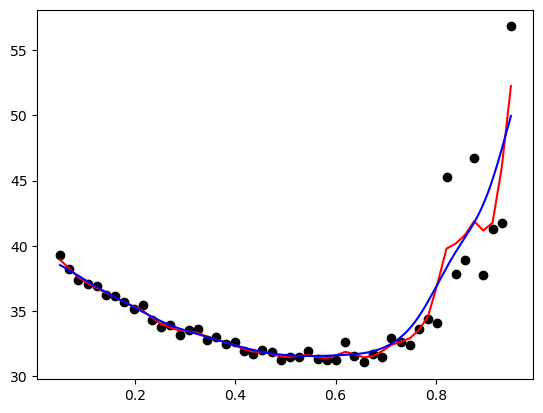

In [127]:
from scipy.interpolate import make_interp_spline, BSpline
from scipy.ndimage import gaussian_filter
phi_smooth = np.linspace(phis.min(), phis.max(), 1000)
spl = make_interp_spline(phis, -np.array(log_posteriors), k=2)
log_posterior_smooth = spl(phi_smooth)

plt.plot(phis, -np.array(log_posteriors), 'ko')
plt.plot(phis, gaussian_filter(-np.array(log_posteriors), 1, mode = 'nearest'), 'r-')
plt.plot(phi_smooth, gaussian_filter(log_posterior_smooth, 50, mode = 'nearest'), 'b-', alpha = 1)



MLE φ ≈ 0.6561
Approx. standard error ≈ 0.0732

--- Profile Likelihood Errors ---
MLE φ ≈ 0.58333
1σ: -0.17568 / +0.12072
2σ: -0.25225 / +0.17748


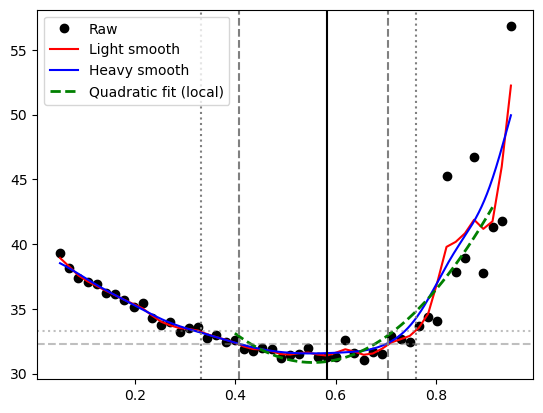

In [138]:
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

neg_log_post = -np.array(log_posteriors)

phi_smooth = np.linspace(phis.min(), phis.max(), 1000)
spl = make_interp_spline(phis, neg_log_post, k=2)
log_posterior_smooth = spl(phi_smooth)

plt.plot(phis, neg_log_post, 'ko', label="Raw")
plt.plot(phis, gaussian_filter(neg_log_post, 1, mode='nearest'),
         'r-', label="Light smooth")
plt.plot(phi_smooth,
         gaussian_filter(log_posterior_smooth, 50, mode='nearest'),
         'b-', alpha=1, label="Heavy smooth")

# -------------------------------------------------------
# LOCAL QUADRATIC FIT AROUND PEAK
# -------------------------------------------------------

# Find minimum (since we plotted negative log posterior)
idx_min = np.argmin(neg_log_post)
phi_hat = phis[idx_min]

# Define window around the peak (adjust fraction if needed)
window_frac = 0.3
window = window_frac * (phis.max() - phis.min())

mask = np.abs(phis - phi_hat) < window

phis_local = phis[mask]
neg_log_local = neg_log_post[mask]

# Fit quadratic: a x^2 + b x + c
coeffs = np.polyfit(phis_local, neg_log_local, 2)
a, b, c = coeffs

# Evaluate quadratic fit
phi_quad = np.linspace(phis_local.min(), phis_local.max(), 400)
quad_fit = a * phi_quad**2 + b * phi_quad + c

plt.plot(phi_quad, quad_fit, 'g--', linewidth=2,
         label="Quadratic fit (local)")

# -------------------------------------------------------
# Estimate curvature-based standard error
# -------------------------------------------------------

# For quadratic approximation of log-likelihood:
# Var(phi_hat) ≈ 1 / (second derivative)
# second derivative of ax^2 + bx + c is 2a

curvature = 2 * a
if curvature > 0:
    se_phi = np.sqrt(1 / curvature)
    print(f"MLE φ ≈ {phi_hat:.4f}")
    print(f"Approx. standard error ≈ {se_phi:.4f}")
else:
    print("Warning: curvature not positive — fit may be unstable.")
    
# -------------------------------------------------------
# PROFILE LIKELIHOOD ERRORS (ASYMMETRIC)
# -------------------------------------------------------

# Use smoothed curve for stability
neg_log_smooth = gaussian_filter(log_posterior_smooth, 12)

min_val = np.min(neg_log_smooth)
phi_hat_smooth = phi_smooth[np.argmin(neg_log_smooth)]

delta = neg_log_smooth - min_val

# Helper function to find crossing
def find_crossing(phi_vals, delta_vals, target, side="left"):

    if side == "left":
        mask = phi_vals < phi_hat_smooth
    else:
        mask = phi_vals > phi_hat_smooth

    phi_side = phi_vals[mask]
    delta_side = delta_vals[mask]

    # find where delta crosses target
    idx = np.where(delta_side >= target)[0]

    if len(idx) == 0:
        return None

    i = idx[0] if side == "right" else idx[-1]

    return phi_side[i]


# 1-sigma (Δ = 1)
phi_left_1 = find_crossing(phi_smooth, delta, 1, "left")
phi_right_1 = find_crossing(phi_smooth, delta, 1, "right")

# 2-sigma (Δ = 2)
phi_left_2 = find_crossing(phi_smooth, delta, 2, "left")
phi_right_2 = find_crossing(phi_smooth, delta, 2, "right")

# Compute asymmetric errors
err_minus_1 = phi_hat_smooth - phi_left_1 if phi_left_1 else None
err_plus_1 = phi_right_1 - phi_hat_smooth if phi_right_1 else None

err_minus_2 = phi_hat_smooth - phi_left_2 if phi_left_2 else None
err_plus_2 = phi_right_2 - phi_hat_smooth if phi_right_2 else None

print("\n--- Profile Likelihood Errors ---")
print(f"MLE φ ≈ {phi_hat_smooth:.5f}")
print(f"1σ: -{err_minus_1:.5f} / +{err_plus_1:.5f}")
print(f"2σ: -{err_minus_2:.5f} / +{err_plus_2:.5f}")

plt.axhline(min_val + 1, color='gray', linestyle='--', alpha=0.5)
plt.axhline(min_val + 2, color='gray', linestyle=':', alpha=0.5)

plt.axvline(phi_hat_smooth, color='black', linestyle='-')

if phi_left_1:
    plt.axvline(phi_left_1, color='gray', linestyle='--')
if phi_right_1:
    plt.axvline(phi_right_1, color='gray', linestyle='--')

if phi_left_2:
    plt.axvline(phi_left_2, color='gray', linestyle=':')
if phi_right_2:
    plt.axvline(phi_right_2, color='gray', linestyle=':')

plt.legend()
plt.show()


(0.0, 20.0)

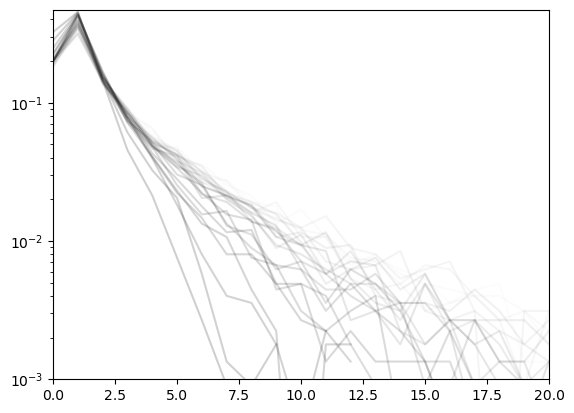

In [139]:
for p, phi in zip(p_models[::2], phis[::2]):
    plt.plot(np.array(p), color = (0, 0, 0, phi/5))
plt.yscale('log')    
plt.ylim(1e-3, 4.7e-1)
plt.xlim(0, 20)


In [101]:
p

array([1.91040874e-01, 3.25651004e-01, 1.39951220e-01, 8.30862149e-02,
       5.24324228e-02, 3.99932029e-02, 3.51063664e-02, 2.00015993e-02,
       2.08901150e-02, 8.89515292e-03, 2.22228886e-02, 9.78366864e-03,
       8.89515292e-03, 7.56237936e-03, 6.22960579e-03, 4.00831651e-03,
       4.45257436e-03, 4.89683222e-03, 1.34276937e-03, 2.23128508e-03,
       2.23128508e-03, 2.23128508e-03, 8.98511514e-04, 9.99580176e-06,
       4.54253658e-04, 8.98511514e-04, 4.54253658e-04, 1.34276937e-03,
       4.54253658e-04, 4.54253658e-04, 9.99580176e-06, 9.99580176e-06,
       4.54253658e-04, 9.99580176e-06, 9.99580176e-06, 4.54253658e-04,
       9.99580176e-06, 9.99580176e-06, 4.54253658e-04, 9.99580176e-06,
       9.99580176e-06, 4.54253658e-04])

In [102]:
p_models[len(p_models)//2]

array([0.19596297, 0.38525087, 0.14530846, 0.09065491, 0.05377487,
       0.0364457 , 0.02133821, 0.01467315, 0.01289579, 0.01245146,
       0.0071194 , 0.00578639, 0.00445338, 0.00178735, 0.00178735,
       0.00178735, 0.00178735, 0.00089867, 0.00134301, 0.00178735,
       0.00089867, 0.00089867, 0.00045434, 0.00045434])

In [90]:
phis

array([0.2       , 0.23684211, 0.27368421, 0.31052632, 0.34736842,
       0.38421053, 0.42105263, 0.45789474, 0.49473684, 0.53157895,
       0.56842105, 0.60526316, 0.64210526, 0.67894737, 0.71578947,
       0.75263158, 0.78947368, 0.82631579, 0.86315789, 0.9       ])

In [74]:
p_obs, p_model

(array([0.18181818, 0.18181818, 0.        , 0.09090909, 0.18181818,
        0.09090909, 0.        , 0.09090909, 0.        , 0.        ,
        0.18181818, 0.        , 0.        ]),
 array([2.22203336e-01, 4.10327028e-01, 1.70358224e-01, 8.44434668e-02,
        4.88925329e-02, 2.96357770e-02, 1.03790211e-02, 1.03790211e-02,
        7.41644327e-03, 1.49128761e-03, 1.49128761e-03, 9.99870017e-06,
        2.97257653e-03]))

In [66]:
# import emcee
# y_obs = [10, 10, 7, 5, 4, 4, 3, 1, 1, 0, 0]

# ndim = 1
# nwalkers = 20

# initial = 0.8 + 0.1*np.random.randn(nwalkers, ndim)

# P, n_sim = 0.3, 3

# cohort_params = {'n_students': 1000}

# sampler = emcee.EnsembleSampler(
#     nwalkers,
#     ndim,
#     log_probability,
#     args=[y_obs, cohort_params, P, n_sim]
# )

# sampler.run_mcmc(initial, 2000)

In [ ]:
applications = np.random.lognormal(mean = np.log(20), sigma = 0.4, size=int(1e3))
# applications[applications>100] = 100 # very rare with our settings but just to make sure
plt.hist(applications, bins = np.arange(max(applications)), histtype = 'step', log = 0);

In [ ]:
np.mean(applications)

In [ ]:
applicant_rank_students = np.random.normal(loc = 0, scale = 1, size = int(7e2)*100)
applicant_rank_postdocs = np.random.normal(loc = 1.2, scale = 0.8, size = int(1e2)*100)

plt.hist(applicant_rank_students, histtype = 'step', bins = 30, log = True);
plt.hist(applicant_rank_postdocs, histtype = 'step', bins = 30, log = True);


In [ ]:
splits = [5,50,200]
tier_max = [10, 10, 3]
def build_prestige(splits, tier_max, decay = 1):
    prestige = []
    
    for n, max_p in zip(splits, tier_max):
        ranks = np.arange(n)
        tier_values = max_p * np.exp(-decay/n * ranks)
        prestige.extend(tier_values)
    
    return np.array(prestige)

build_prestige(splits, tier_max, decay = 1)

In [ ]:
import numpy as np


class ApplicantCohort:

    def __init__(
        self,
        n_students=1000,
        n_postdocs=300,
        splits=(6, 50, 200),
        frac_student_applying=0.75,
        frac_postdoc_applying=1/3,
        mean_applications=np.log(30),
        sigma_applications=0.4,
        tier_max_prestige=(15, 8, 3),
        prestige_decays=(1.0, 1.5, 1.2),
        minimum_prestiges=(5, 2, 0.5),
        loc_postdoc=1.15,
        scale_postdoc=0.8,
        loc_student=0,
        scale_student=1,
        self_awareness=0.4,
        stochasticity=0.9
    ):

        # --------------------
        # Population
        # --------------------
        self.n_students = n_students
        self.n_postdocs = n_postdocs

        self.n_student_applying = int(n_students * frac_student_applying)
        self.n_postdoc_applying = int(n_postdocs * frac_postdoc_applying)

        # --------------------
        # Skill distributions
        # --------------------
        student_skills = np.random.normal(loc_student, scale_student,
                                          self.n_student_applying)

        postdoc_skills = np.random.normal(loc_postdoc, scale_postdoc,
                                          self.n_postdoc_applying)

        skills = np.concatenate([student_skills, postdoc_skills])
        labels = np.array(
            ["student"] * self.n_student_applying +
            ["postdoc"] * self.n_postdoc_applying
        )

        order = np.argsort(-skills)
        self.skills = skills[order]
        self.labels = labels[order]

        self.N_applicants = len(self.skills)

        # --------------------
        # Applications per applicant
        # --------------------
        mean_postdoc = np.log(np.exp(mean_applications) / 2)

        self.n_applications = np.zeros(self.N_applicants, dtype=int)

        for i, lab in enumerate(self.labels):
            if lab == "student":
                k = np.random.lognormal(mean_applications, sigma_applications)
            else:
                k = np.random.lognormal(mean_postdoc, sigma_applications)

            self.n_applications[i] = int(max(1, k))

        # --------------------
        # Prestige structure
        # --------------------
        self.prestige = self._build_prestige(
            splits,
            tier_max_prestige,
            prestige_decays,
            minimum_prestiges
        )

        self.N_positions = len(self.prestige)

        # --------------------
        # Selectivity
        # --------------------
        self.self_awareness = np.clip(self_awareness, 0, 0.8)
        self.stochasticity = stochasticity

        # --------------------
        # State containers
        # --------------------
        self.application_lists = None
        self.pools = None
        self.rankings = None

        self.job_pointer = None
        self.applicant_match = np.full(self.N_applicants, -1)
        self.job_match = np.full(self.N_positions, -1)

    # =====================================================
    # Prestige construction
    # =====================================================

    def _build_prestige(self, splits, max_vals, decays, mins):

        prestige = []

        for n, max_p, decay, min_p in zip(splits, max_vals, decays, mins):

            ranks = np.arange(n)
            tier_vals = min_p + (max_p - min_p) * np.exp(-decay * ranks / n)
            prestige.extend(tier_vals)

        return np.array(prestige)

    # =====================================================
    # Application generation
    # =====================================================

    def generate_applications(self):

        self.application_lists = [[] for _ in range(self.N_applicants)]
        self.pools = [[] for _ in range(self.N_positions)]

        max_skill = np.max(np.abs(self.skills))

        for i in range(self.N_applicants):

            beta = 1 + self.self_awareness * self.skills[i] / max_skill

            logits = beta * self.prestige
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()

            k = min(self.n_applications[i], self.N_positions)

            chosen = np.random.choice(
                self.N_positions,
                size=k,
                replace=False,
                p=probs
            )

            self.application_lists[i] = list(chosen)

            for j in chosen:
                self.pools[j].append(i)

    # =====================================================
    # Employer rankings (Mallows-style noise)
    # =====================================================

    def evaluate_pools(self):

        self.rankings = []

        for pool in self.pools:

            if len(pool) == 0:
                self.rankings.append([])
                continue

            pool_skills = self.skills[pool]

            noise = np.random.normal(
                scale=(1 - self.stochasticity),
                size=len(pool_skills)
            )

            score = pool_skills + noise
            ranked_indices = np.argsort(-score)

            ranked_applicants = [pool[i] for i in ranked_indices]
            self.rankings.append(ranked_applicants)

        self.job_pointer = np.zeros(self.N_positions, dtype=int)

    # =====================================================
    # Deferred acceptance
    # =====================================================

    def run_market(self, max_rounds=30):

        self.generate_applications()
        self.evaluate_pools()

        for _ in range(max_rounds):

            new_offers = []

            # Each open job proposes
            for j in range(self.N_positions):

                if self.job_match[j] != -1:
                    continue

                pointer = self.job_pointer[j]

                if pointer >= len(self.rankings[j]):
                    continue

                candidate = self.rankings[j][pointer]
                self.job_pointer[j] += 1

                new_offers.append((j, candidate))

            if len(new_offers) == 0:
                break

            # Applicants choose best offer
            offers_by_applicant = {}

            for j, i in new_offers:
                offers_by_applicant.setdefault(i, []).append(j)

            for i, jobs in offers_by_applicant.items():

                # applicant also considers existing match
                if self.applicant_match[i] != -1:
                    jobs.append(self.applicant_match[i])

                best_job = max(jobs, key=lambda x: self.prestige[x])

                # reject all others
                for j in jobs:
                    if j != best_job:
                        self.job_match[j] = -1

                self.applicant_match[i] = best_job
                self.job_match[best_job] = i

        return self.applicant_match, self.job_match


In [ ]:
Cohort = ApplicantCohort()
apps, jobs = Cohort.run_market()

In [ ]:
jobs

In [ ]:
import numpy as np


class ApplicantCohort:

    def __init__(
        self,
        n_students=1000,
        n_postdocs=300,
        splits=(6, 50, 200),
        frac_student_applying=0.75,
        frac_postdoc_applying=1/3,
        mean_applications=np.log(30),
        sigma_applications=0.4,
        tier_max_prestige=(15, 8, 3),
        prestige_decays=(1.0, 1.5, 1.2),
        minimum_prestiges=(5, 2, 0.5),
        loc_postdoc=1.15,
        scale_postdoc=0.8,
        loc_student=0,
        scale_student=1,
        self_awareness=0.4,
        stochasticity=0.9,
        verbose=1
    ):

        self.verbose = verbose

        # --------------------
        # Population
        # --------------------
        self.n_student_applying = int(n_students * frac_student_applying)
        self.n_postdoc_applying = int(n_postdocs * frac_postdoc_applying)

        student_skills = np.random.normal(loc_student, scale_student,
                                          self.n_student_applying)

        postdoc_skills = np.random.normal(loc_postdoc, scale_postdoc,
                                          self.n_postdoc_applying)

        skills = np.concatenate([student_skills, postdoc_skills])
        labels = np.array(
            ["student"] * self.n_student_applying +
            ["postdoc"] * self.n_postdoc_applying
        )

        order = np.argsort(-skills)
        self.skills = skills[order]
        self.labels = labels[order]

        self.N_applicants = len(self.skills)

        # --------------------
        # Applications per applicant
        # --------------------
        mean_postdoc = np.log(np.exp(mean_applications) / 2)

        self.n_applications = np.zeros(self.N_applicants, dtype=int)

        for i, lab in enumerate(self.labels):
            if lab == "student":
                k = np.random.lognormal(mean_applications, sigma_applications)
            else:
                k = np.random.lognormal(mean_postdoc, sigma_applications)

            self.n_applications[i] = int(max(1, k))

        # --------------------
        # Prestige
        # --------------------
        self.prestige = self._build_prestige(
            splits,
            tier_max_prestige,
            prestige_decays,
            minimum_prestiges
        )

        self.N_positions = len(self.prestige)

        self.self_awareness = np.clip(self_awareness, 0, 0.8)
        self.stochasticity = stochasticity

        # --------------------
        # State
        # --------------------
        self.application_lists = None
        self.pools = None
        self.rankings = None

        self.job_pointer = None
        self.applicant_match = np.full(self.N_applicants, -1)
        self.job_match = np.full(self.N_positions, -1)

    # =====================================================
    # Prestige
    # =====================================================

    def _build_prestige(self, splits, max_vals, decays, mins):

        prestige = []

        for n, max_p, decay, min_p in zip(splits, max_vals, decays, mins):

            ranks = np.arange(n)
            tier_vals = min_p + (max_p - min_p) * np.exp(-decay * ranks / n)
            prestige.extend(tier_vals)

        return np.array(prestige)

    # =====================================================
    # Applications
    # =====================================================

    def generate_applications(self):

        if self.verbose >= 1:
            print("Generating applications...")

        self.application_lists = [[] for _ in range(self.N_applicants)]
        self.pools = [[] for _ in range(self.N_positions)]

        max_skill = np.max(np.abs(self.skills))

        for i in range(self.N_applicants):

            beta = 1 + self.self_awareness * self.skills[i] / max_skill

            logits = beta * self.prestige
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()

            k = min(self.n_applications[i], self.N_positions)

            chosen = np.random.choice(
                self.N_positions,
                size=k,
                replace=False,
                p=probs
            )

            self.application_lists[i] = list(chosen)

            for j in chosen:
                self.pools[j].append(i)

        if self.verbose >= 1:
            pool_sizes = [len(p) for p in self.pools]
            print(f"Mean pool size: {np.mean(pool_sizes):.2f}")
            print(f"Max pool size: {np.max(pool_sizes)}")

    # =====================================================
    # Employer evaluation
    # =====================================================

    def evaluate_pools(self):

        if self.verbose >= 1:
            print("Evaluating applicant pools...")

        self.rankings = []

        for j, pool in enumerate(self.pools):

            if len(pool) == 0:
                self.rankings.append([])
                continue

            pool_skills = self.skills[pool]

            noise = np.random.normal(
                scale=(1 - self.stochasticity),
                size=len(pool_skills)
            )

            score = pool_skills + noise
            ranked_indices = np.argsort(-score)
            ranked_applicants = [pool[i] for i in ranked_indices]

            self.rankings.append(ranked_applicants)

        self.job_pointer = np.zeros(self.N_positions, dtype=int)

    # =====================================================
    # Market
    # =====================================================

    def run_market(self, max_rounds=20):

        self.generate_applications()
        self.evaluate_pools()

        for r in range(max_rounds):

            if self.verbose >= 1:
                print(f"\n--- Round {r+1} ---")

            new_offers = []

            for j in range(self.N_positions):

                if self.job_match[j] != -1:
                    continue

                pointer = self.job_pointer[j]

                if pointer >= len(self.rankings[j]):
                    continue

                candidate = self.rankings[j][pointer]
                self.job_pointer[j] += 1

                new_offers.append((j, candidate))

                if self.verbose >= 2:
                    print(f"Job {j} proposes to applicant {candidate}")

            if len(new_offers) == 0:
                if self.verbose >= 1:
                    print("No more proposals possible.")
                break

            offers_by_applicant = {}

            for j, i in new_offers:
                offers_by_applicant.setdefault(i, []).append(j)

            for i, jobs in offers_by_applicant.items():

                if self.applicant_match[i] != -1:
                    jobs.append(self.applicant_match[i])

                best_job = max(jobs, key=lambda x: self.prestige[x])

                for j in jobs:
                    if j != best_job:
                        self.job_match[j] = -1

                self.applicant_match[i] = best_job
                self.job_match[best_job] = i

                if self.verbose >= 2:
                    print(f"Applicant {i} accepts job {best_job}")

            if self.verbose >= 1:
                filled = np.sum(self.job_match != -1)
                print(f"Filled positions: {filled}/{self.N_positions}")

        return self._build_output()

    # =====================================================
    # Output
    # =====================================================

    def _build_output(self):

        applicants = []

        for i in range(self.N_applicants):

            job = self.applicant_match[i]

            applicant_dict = {
                "rank": i,
                "label": self.labels[i],
                "skill": self.skills[i],
                "n_applications": self.n_applications[i],
                "applications_sent": self.application_lists[i],
                "matched_job": job,
                "matched_prestige": None if job == -1 else self.prestige[job]
            }

            applicants.append(applicant_dict)

        return applicants


In [ ]:
Cohort = ApplicantCohort(verbose=1)
results = Cohort.run_market(max_rounds=20)


In [ ]:
# results